In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
from esm.utils.constants.esm3 import (
    SEQUENCE_MASK_TOKEN,
)
import torch
device = torch.device('cuda:0')
model = ESMC.from_pretrained("esmc_600m").to(device) # or "cpu"

from Bio import SeqIO
sequences = [str(s.seq).upper() for s in SeqIO.parse('../../data/disordered_prot.fasta', 'fasta')]

vocab = model.tokenizer.get_vocab()
aa_list = [None]*20
for aa, i in vocab.items():
    if(4 <= i < 24):
        aa_list[i-4] = aa
AA_str = ''.join(aa_list)

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
from go_ml.data_utils import load_protein_sequences
prot_sequences, seq_ids = load_protein_sequences(f"/home/andrew/GO_interp/data/elm/lig_elm_instances.fasta")

In [ ]:
from go_ml.masking import mask_range

In [ ]:
def mask_batch(seq_batch, mut_per=0.15):
    batch_size, seq_len = seq_batch.shape
    seq_len = torch.LongTensor([seq_len - 2]) #Discount SOS and EOS tokens at start and end
    mut_count = torch.floor(seq_len*mut_per).int().item()
    mut_inds = torch.stack([torch.randperm(seq_len) for _ in range(batch_size)])[:, :mut_count] + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)
    update_batch = seq_batch.clone()
    update_batch[batch_inds, mut_inds] = SEQUENCE_MASK_TOKEN
    return update_batch

def batch_sample(seq_batch):
    update_batch = mask_batch(seq_batch)
    with torch.no_grad():
        model_eval = model(update_batch)
        bert_eval = model_eval.logits
        bert_eval = torch.softmax(bert_eval, dim=2)
        N, L, T = bert_eval.shape
    sample_tokens = torch.multinomial(bert_eval.reshape(N*L, T), num_samples=1).reshape(N, L)
    update_batch[seq_batch == SEQUENCE_MASK_TOKEN] = sample_tokens
    return update_batch, bert_eval

def gibbs_sampler(seq, mask_func, num_iter=16, batch_size=8):
    seq_ind = model.encode(ESMProtein(sequence=seq)).sequence.to(device)
    mask_batch_sample_l = []
    batch_sample_l = [] 
    bert_eval_l = []
    seq_batch = torch.tile(seq_ind.reshape(1, -1), (batch_size, 1))
    with torch.no_grad():
        for _ in range(num_iter):
            update_batch = mask_func(seq_batch)
            batch_sample_l.append(seq_batch.cpu())
            mask_batch_sample_l.append(update_batch.cpu()) #Save masked batch
            model_eval = model(update_batch)
            bert_eval = model_eval.sequence_logits
            bert_eval = torch.softmax(bert_eval[..., 4:24], dim=2)
            N, L, T = bert_eval.shape
            sample_tokens = torch.multinomial(bert_eval.reshape(N*L, T), num_samples=1).reshape(N, L)+4
            update_batch = update_batch * (update_batch != SEQUENCE_MASK_TOKEN) + sample_tokens * (update_batch == SEQUENCE_MASK_TOKEN)
            bert_eval_l.append(bert_eval.cpu())
            seq_batch = update_batch
    return torch.stack(bert_eval_l), torch.stack(batch_sample_l).cpu(), torch.stack(mask_batch_sample_l).cpu()

In [5]:
gibbs_batch_l = []
for i in range(15):
    _, gibbs_batch, _ = gibbs_sampler(sequences[0], mask_func=lambda seq_batch: mask_batch(seq_batch, mut_per=0.15),
                                      num_iter=25, batch_size=25)
    gibbs_batch_l.append(gibbs_batch)
gibbs_batch = torch.cat(gibbs_batch_l)
gibbs_batch = gibbs_batch.reshape(-1, gibbs_batch.shape[-1])

In [12]:
vocab = model.tokenizer.get_vocab()
[vocab[a]-4 for a in 'FG']

[14, 2]

In [15]:
def seq_kmers(seq_ind, k=3):
    kmer_stats = torch.zeros([20]*k)
    # sp = torch.stack([seq_ind[:-1], seq_ind[1:]])
    for i in range(1, 1+seq_ind.shape[0]-k):
        kmer_ind = tuple(seq_ind[i:i+k]-4)
        kmer_stats[kmer_ind] += 1
    return kmer_stats

batch_kmers = torch.stack([seq_kmers(gibbs_batch[i], k=2) for i in range(gibbs_batch.shape[0])])
batch_kmers.shape

torch.Size([9375, 20, 20])

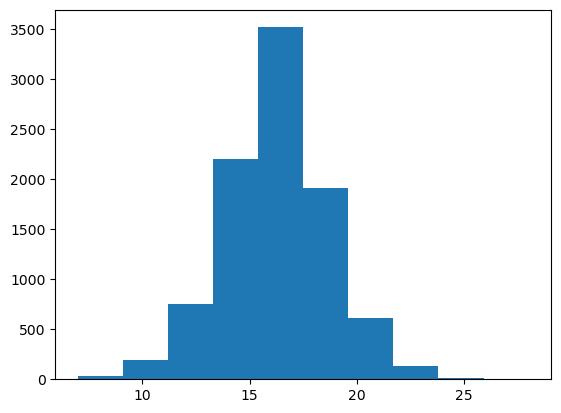

In [28]:
plt.hist(batch_kmers[:, 14, 2])
plt.show()

In [ ]:
residue_frac = torch.nn.functional.one_hot(gibbs_batch[:, 1:-1]-4, num_classes=20).float().mean(dim=1)
rf_mean = residue_frac.mean(dim=0, keepdim=True)

fig, axs = plt.subplots(10, 2, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.hist(residue_frac[:, i], bins=np.linspace(0, 0.2, 50))
    ax.set_title(AA_str[i])
fig.tight_layout()
fig.show()

In [ ]:
from tqdm.notebook import tqdm
def local_gibbs_statistics(seq, segment_len=15, step_size=5, num_iter=16):
    si_l = []
    batch_sample_l = []
    for si in tqdm(range(1, len(seq)+1-segment_len, step_size)):
        ei = si+segment_len
        mask_func = lambda seq_batch: mask_range(seq_batch, si, ei, mut_per=0.15)
        bert_eval, batch_sample, mask_batch_sample = gibbs_sampler(seq, mask_func=mask_func, num_iter=num_iter, batch_size=8)
        si_l.append(si); batch_sample_l.append(batch_sample[..., si:ei])
    return si_l, batch_sample_l

fg_window_stat = local_gibbs_statistics(sequences[0], segment_len=45, step_size=20, num_iter=32)
si_l, gibbs_batch_l = fg_window_stat

  0%|          | 0/25 [00:00<?, ?it/s]

In [87]:
rf_l = []
for gibbs_batch in fg_window_stat[1]:
    residue_frac = torch.nn.functional.one_hot(gibbs_batch[:, :]-4, num_classes=20).float().sum(dim=-2).reshape(-1, 20)
    rf_l.append(residue_frac)

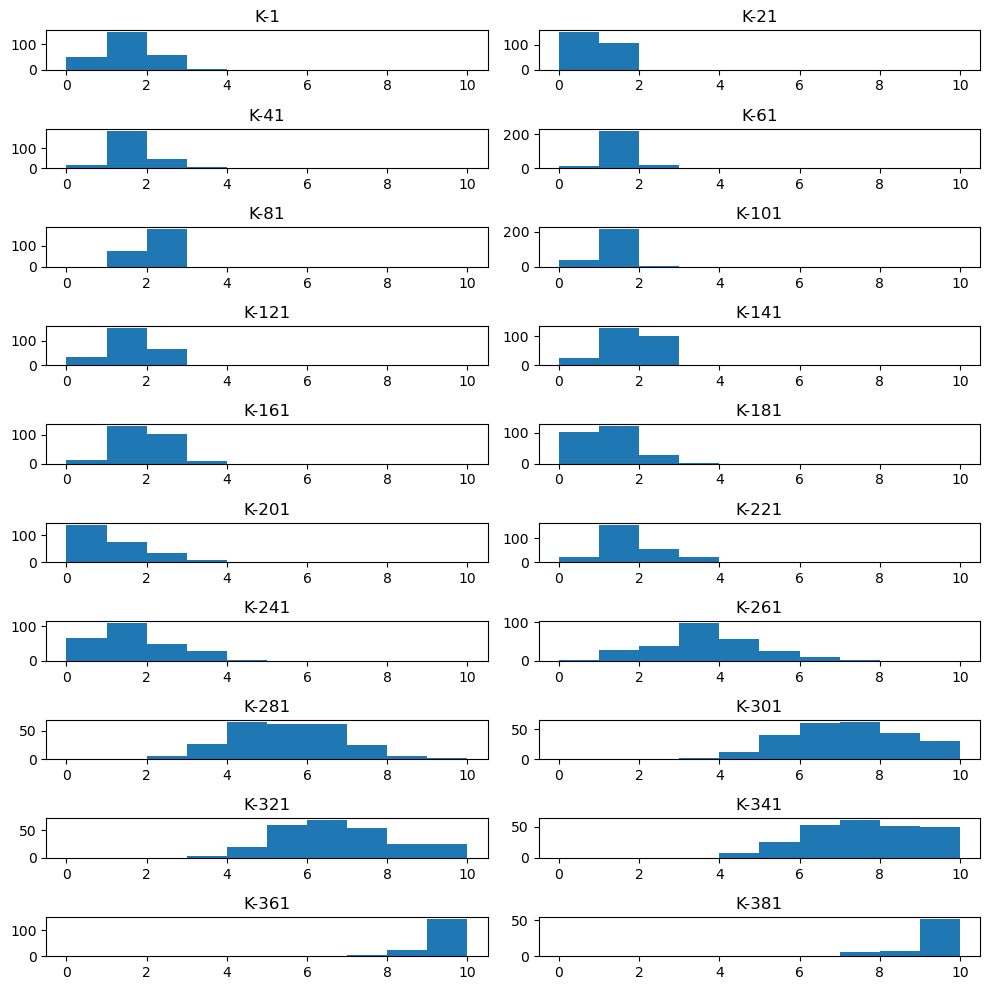

In [89]:
fig, axs = plt.subplots(10, 2, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    aa_ind = vocab['K']-4
    h_ind, k_ind, r_ind = vocab['H']-4, vocab['K']-4, vocab['R']-4
    ax.hist(rf_l[i][:, h_ind]+rf_l[i][:, k_ind]+rf_l[i][:, r_ind], bins=np.linspace(0, 10, 11))
    ax.set_title(f"{AA_str[aa_ind]}-{si_l[i]}")
fig.tight_layout()
fig.show()

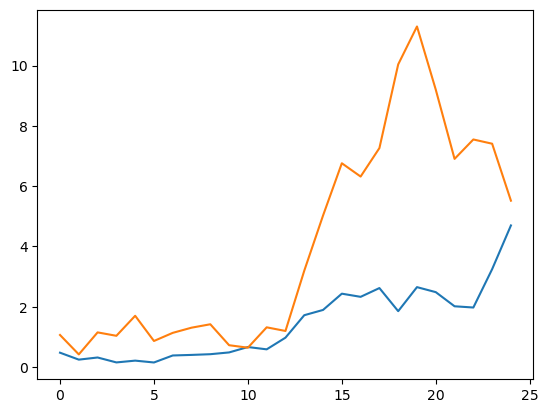

In [90]:
pos_frac_l = [rf[:, [h_ind, k_ind, r_ind]].sum(dim=1) for rf in rf_l]
plt.plot([pf.var() for pf in pos_frac_l])
plt.plot([pf.mean() for pf in pos_frac_l])


In [102]:
data = {si: rf[:, [h_ind, k_ind, r_ind]].sum(dim=1) for si, rf in zip(si_l, rf_l)}

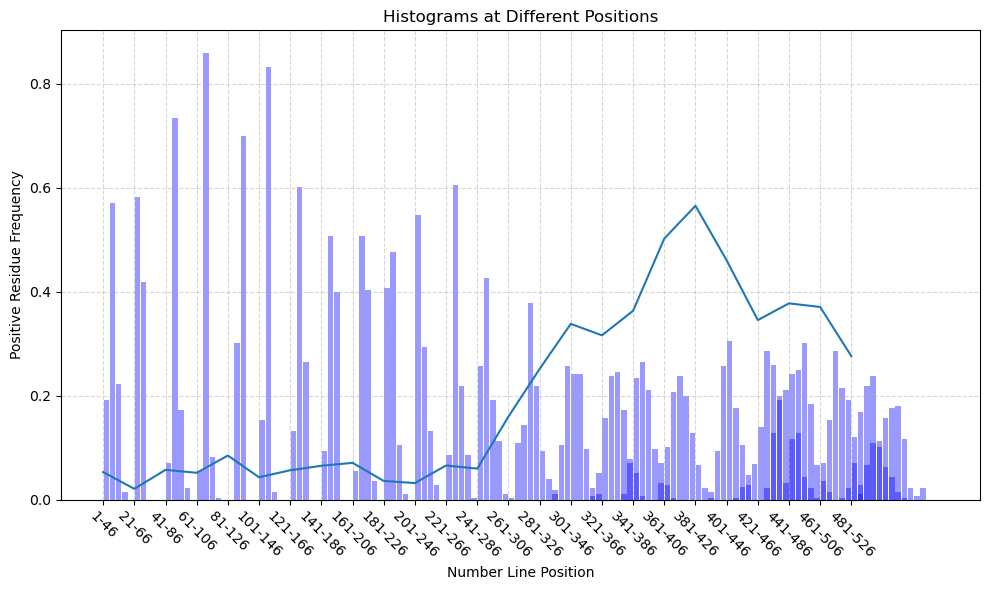

In [103]:
# Parameters
bin_count = 15  # Number of bins for histograms
bar_width = 3.5  # Width of the histogram bars

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each histogram at its numerical position
for position, values in data.items():
    # Generate histogram data
    counts, bins = np.histogram(values, bins=np.arange(bin_count))
    counts = counts.astype('float') / counts.sum()

    bins *= 4
    bin_centers = (bins[:-1] + bins[1:]) / 2
    # Shift bin centers to position on the number line
    shifted_centers = bin_centers + position
    # Plot bars
    ax.bar(shifted_centers, counts, width=bar_width, alpha=0.4, color='blue', label=f'Position {position}')

ax.set_xticks(si_l)
ax.set_xticklabels([f"{si}-{si+45}" for si in si_l], rotation=-45)

# Customize plot
ax.set_xlabel("Number Line Position")
ax.set_ylabel("Positive Residue Frequency")
ax.set_title("Histograms at Different Positions")

ax.plot(si_l, [data[si].mean()*0.05 for si in si_l])
# ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show plot
plt.show()

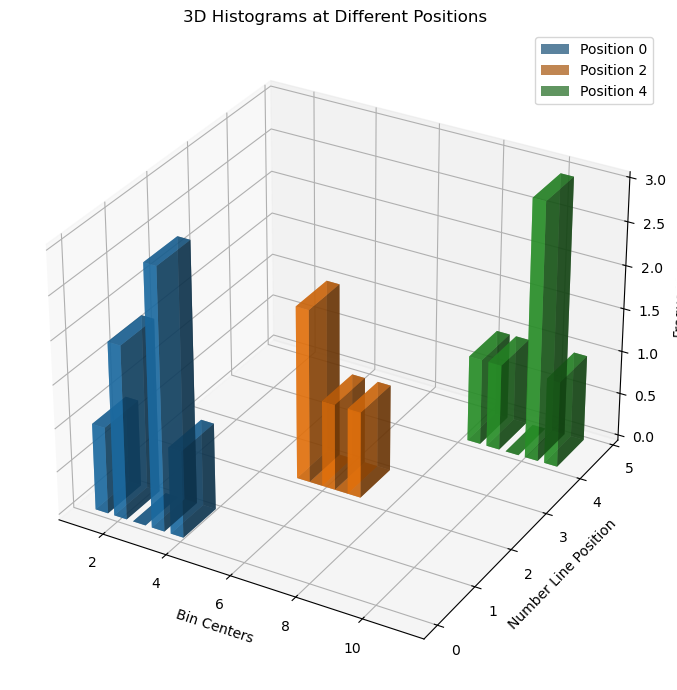

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Example data
data = {
    0: [1, 2, 2, 3, 3, 3, 4],
    2: [5, 5, 6, 7],
    4: [8, 9, 10, 10, 10, 11],
}

# Parameters
bin_count = 5  # Number of bins for histograms
bar_width = 0.4  # Width of the histogram bars
depth = 0.8  # Depth of the bars in the 3D plot

# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot each histogram at its numerical position
for position, values in data.items():
    # Generate histogram data
    counts, bins = np.histogram(values, bins=bin_count)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Bar positions (x, y, z)
    x_positions = bin_centers
    y_positions = np.full_like(bin_centers, position)  # Position on the number line
    z_positions = np.zeros_like(bin_centers)  # Start bars from z=0

    # Bar dimensions
    dx = np.full_like(bin_centers, bar_width)
    dy = np.full_like(bin_centers, depth)
    dz = counts

    # Plot the 3D bars
    ax.bar3d(x_positions, y_positions, z_positions, dx, dy, dz, alpha=0.7, label=f'Position {position}')

# Customize plot
ax.set_xlabel("Bin Centers")
ax.set_ylabel("Number Line Position")
ax.set_zlabel("Frequency")
ax.set_title("3D Histograms at Different Positions")
plt.tight_layout()
plt.legend()

# Show plot
plt.show()

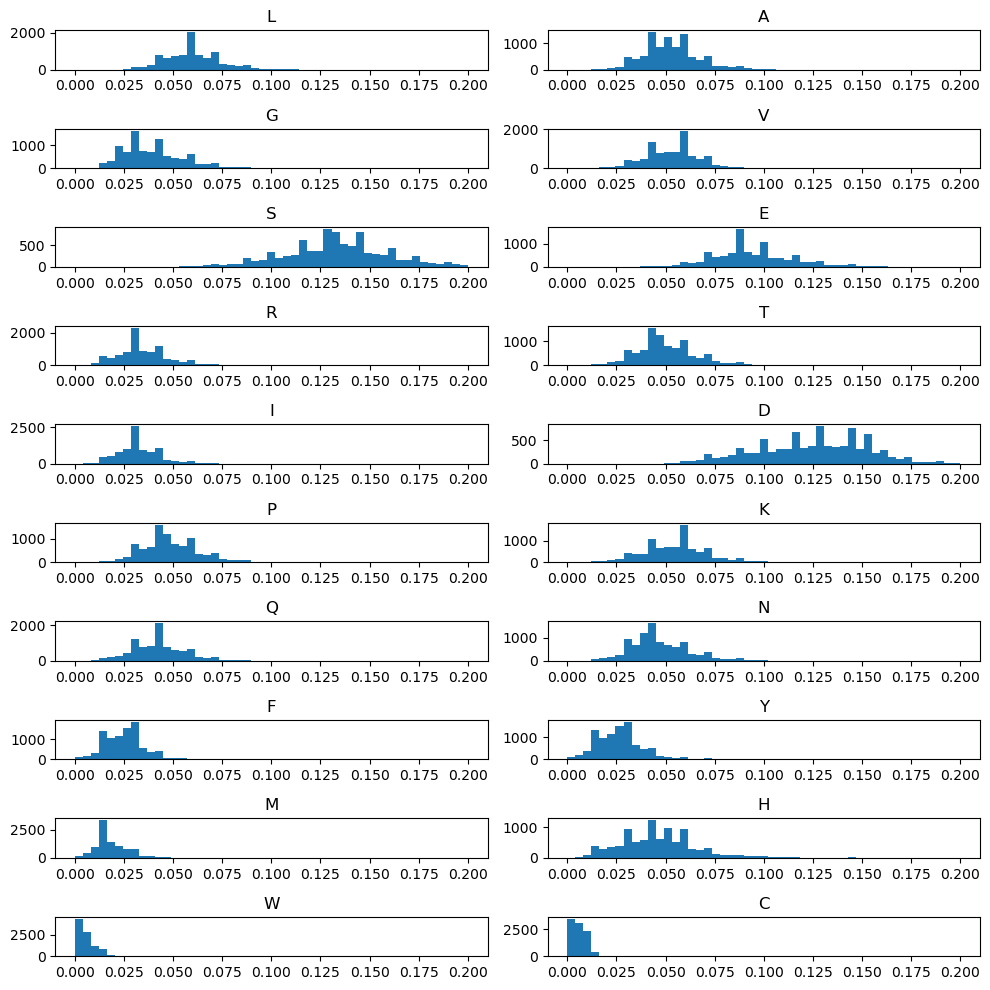

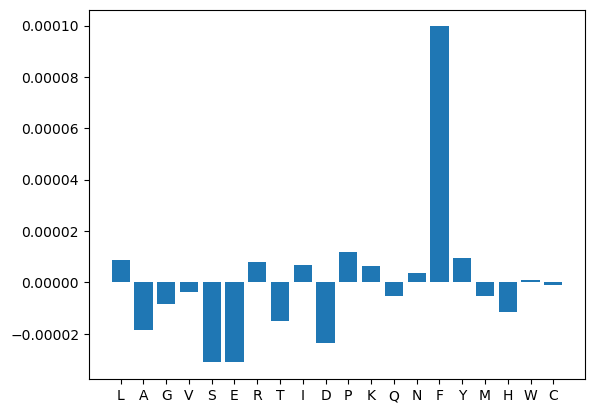

In [20]:
cov = np.cov(residue_frac-rf_mean, rowvar=False)
plt.bar(np.arange(20), cov[vocab['F']-4])
plt.xticks(np.arange(20), aa_str)
plt.show()

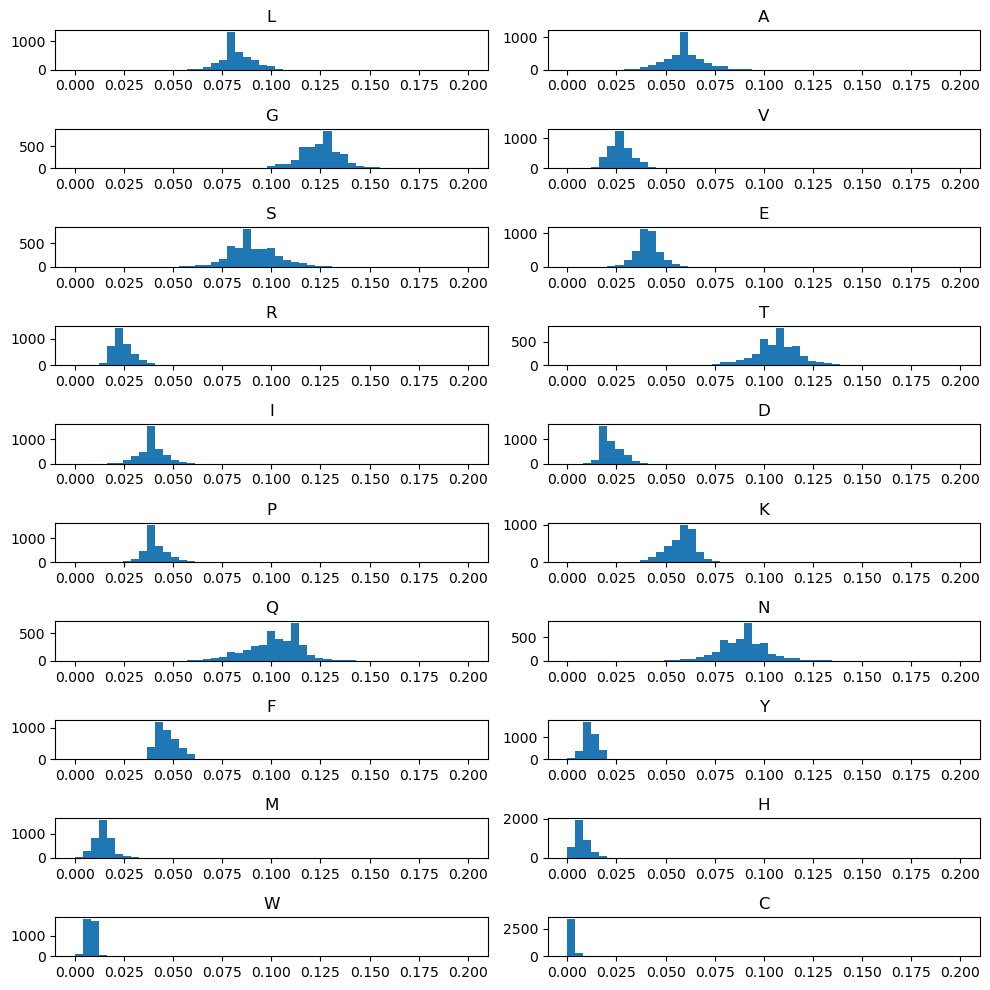

In [ ]:
fig, axs = plt.subplots(10, 2, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.hist(residue_frac[:, i], bins=np.linspace(0, 0.2, 50))
    ax.set_title(aa_str[i])
fig.tight_layout()
fig.show()

cov = np.cov(residue_frac-rf_mean, rowvar=False)
plt.bar(np.arange(20), cov[vocab['L']-4])
plt.xticks(np.arange(20), aa_str)
plt.show()

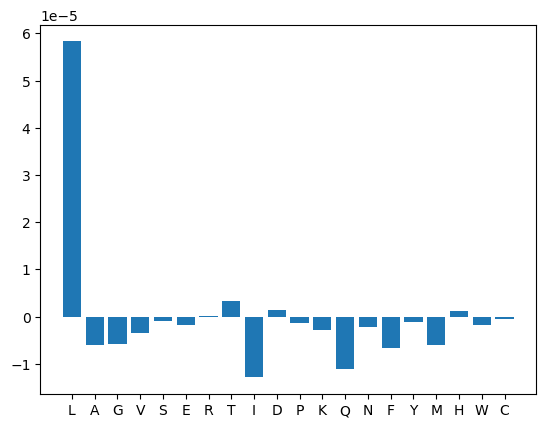

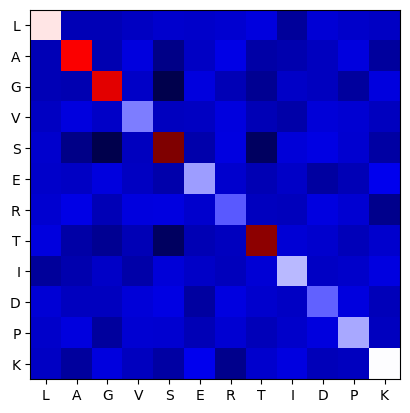

In [26]:
cov = np.cov(residue_frac-rf_mean, rowvar=False)[:12, :12]
import matplotlib as mpl
cmap = mpl.colormaps.get_cmap('seismic')
print(cmap)
plt.imshow(cov, cmap=cmap)
plt.xticks(np.arange(cov.shape[0]), aa_list[:cov.shape[0]])
plt.yticks(np.arange(cov.shape[1]), aa_list[:cov.shape[1]])
plt.show()

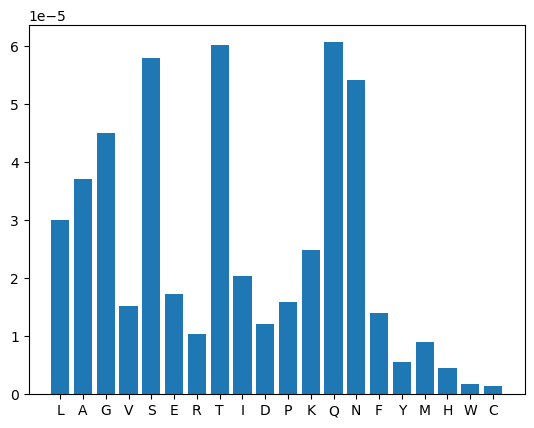

In [123]:
plt.bar(np.arange(20), np.var(residue_frac.cpu().numpy(), axis=0))
plt.xticks(np.arange(20), aa_list)
plt.show()

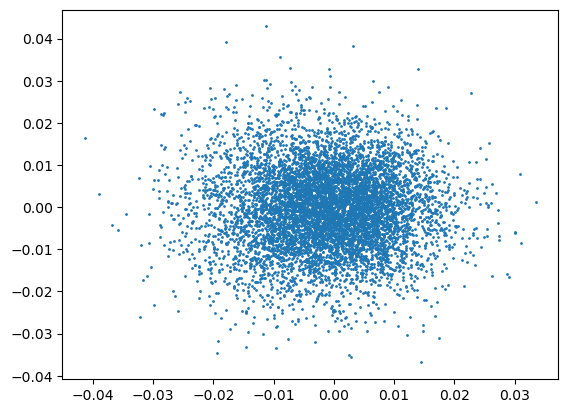

In [98]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rf_red = pca.fit_transform(residue_frac.cpu().numpy())
plt.scatter(rf_red[:, 0], rf_red[:, 1], s=1)
plt.show()

In [112]:
pca.mean_.shape
pca.components_.shape

(2, 20)

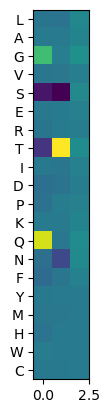

In [ ]:
plt.imshow(np.concatenate([pca.components_, pca.mean_.reshape((1, -1))]).T)
plt.yticks(np.arange(20), aa_list)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Parameters of the multivariate Gaussian
mean = np.array([0, 0])  # Replace with your mean vector [mean_x, mean_y]
covariance = np.array([[2.0, 0.5], [0.5, 1.0]])  # Replace with your 2x2 covariance matrix

# Create a grid of (x, y) points
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)

# Evaluate the Gaussian on the grid
pos = np.dstack((X, Y))  # Create (x, y) pairs for each point on the grid
rv = multivariate_normal(mean, covariance)  # Define the multivariate normal
Z = rv.pdf(pos)  # Compute the probability density function at each point

# Plot the contour plot
plt.figure(figsize=(8, 6))
contour = plt.contour(X, Y, Z, levels=10, cmap='viridis')
plt.clabel(contour, inline=1, fontsize=10)
plt.title('Contour Plot of a Multivariate Gaussian')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.colorbar(label='Probability Density')
plt.show()

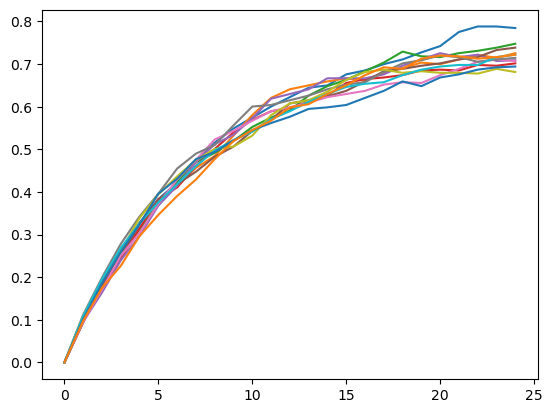

In [35]:
import matplotlib.pyplot as plt
base_seq = model.encode(ESMProtein(sequences[ind])).sequence.cpu()
hamming_drift = (gibbs_batch != base_seq.reshape(1, 1, -1)).sum(dim=-1)
for i in range(hamming_drift.shape[1]):
    plt.plot(hamming_drift[:, i] / base_seq.shape[0])
plt.show()